# Módulo 1: Introducción y Preparativos

**Objetivo**
- Aprender a resolver problemas empresariales utilizando Machine Learning.
- Crear un pipeline completo, desde la exploración de datos hasta la implementación de un modelo predictivo.

**Problema a Resolver**

Usaremos el dataset ***"Heart Disease Dataset"*** de Kaggle. Este conjunto de datos data de 1988 y consta de cuatro bases de datos: Cleveland, Hungría, Suiza y Long Beach V. Contiene 76 atributos, incluido el atributo de predicción, pero todos los experimentos publicados hacen referencia al uso de un subconjunto de 14 de ellos. El campo «objetivo» se refiere a la presencia de cardiopatía en el paciente. Tiene valor entero 0 = sin enfermedad y 1 = enfermedad.

## Configuración del Entorno

Instalar siguientes librerías:
`pip install -r requirements.txt`

Descargar dataset [Kaggle: Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)

## Carga e Introducción al Dataset

In [93]:
# Importar librerías esenciales
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

from scipy.stats import ttest_ind
from itertools import combinations

from lazypredict.Supervised import LazyClassifier
import optuna

import shap
import pickle

shap.initjs()

In [4]:
# Cargar dataset
data = pd.read_csv('../data/input/heart.csv')

In [5]:
# Primera vista al dataset
print('Tamaño del dataset:', data.shape)
print('Visualización de las primeras filas')
display(data.head())

Tamaño del dataset: (1025, 14)
Visualización de las primeras filas


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.00,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.10,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.60,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.00,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.90,1,3,2,0


1. age
2. sex
3. chest pain type (4 values)
4. resting blood pressure
5. serum cholestoral in mg/dl
6. fasting blood sugar > 120 mg/dl
7. resting electrocardiographic results (values 0,1,2)
8. maximum heart rate achieved
9. exercise induced angina
10. oldpeak = ST depression induced by exercise relative to rest
11. the slope of the peak exercise ST segment
12. number of major vessels (0-3) colored by flourosopy
13. thal: 0 = normal; 1 = fixed defect; 2 = reversable defect
14. target

In [6]:
# Información básica del dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
# Resumen estadístico
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


## Exploración de la Variable Objetivo
La variable objetivo será la presencia de enfermedades cardiacas

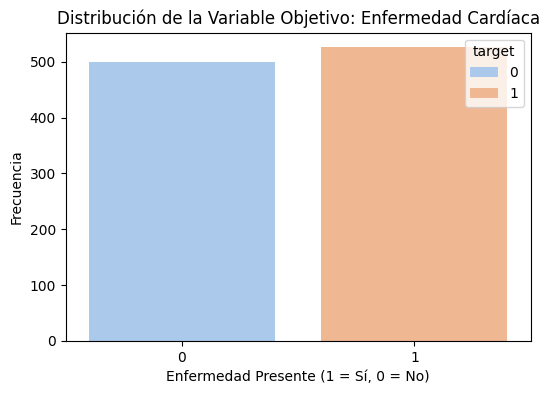

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=data, palette="pastel", hue="target")
plt.title("Distribución de la Variable Objetivo: Enfermedad Cardíaca")
plt.xlabel("Enfermedad Presente (1 = Sí, 0 = No)")
plt.ylabel("Frecuencia")
plt.show()

Como conclusión de este paso vemos:
1. Dataset no presenta valores faltantes o nulos
2. Clase 1 (Enfermedad Presente) tiene mayor frecuencia que la clase 0 (Sin enfermedad). Esto sugiere que las clases no están perfectamente balanceadas, pero no hay un desbalance extremo.
3. Dataset presenta variables de tipo continuo, binario y categórico

# Módulo 2: Análisis Exploratorio de Datos (EDA)
En este módulo realizaremos:
1. Análisis descriptivo de las variables.
2. Visualización de correlaciones entre variables.
3. Identificación de valores atípicos y patrones en los datos.

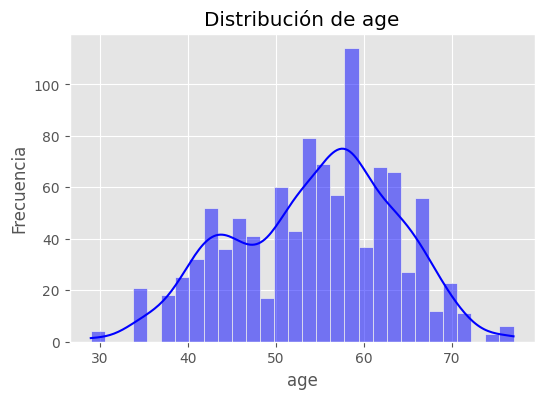

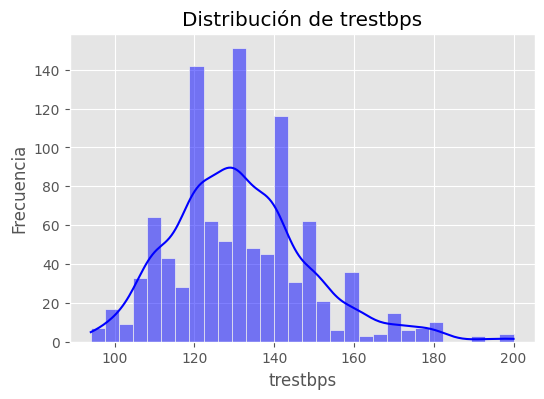

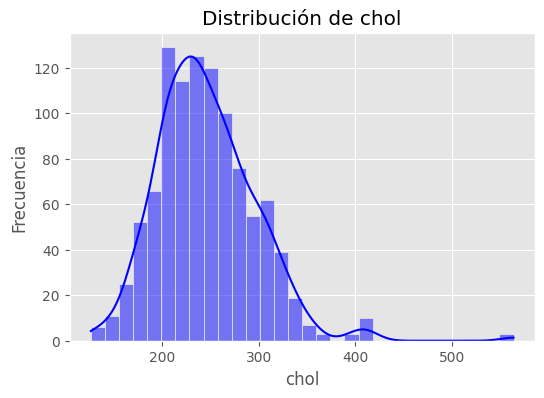

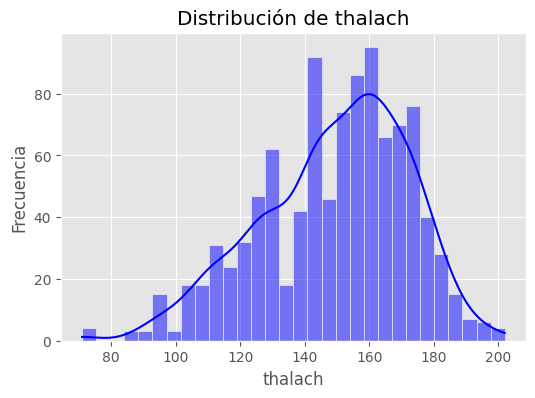

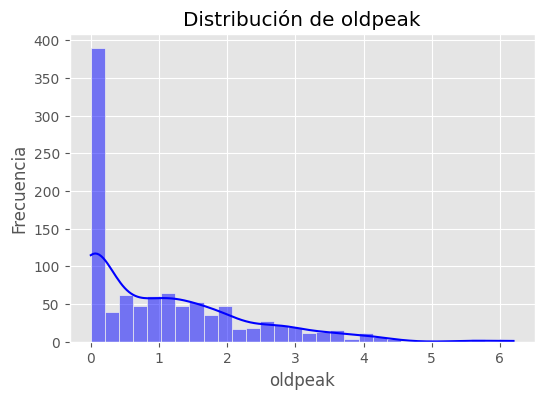

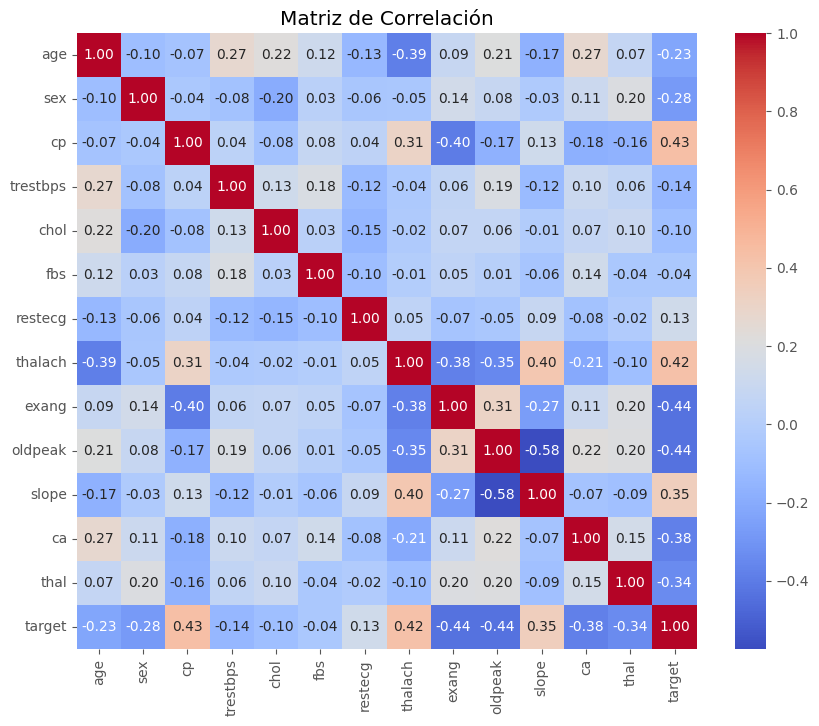

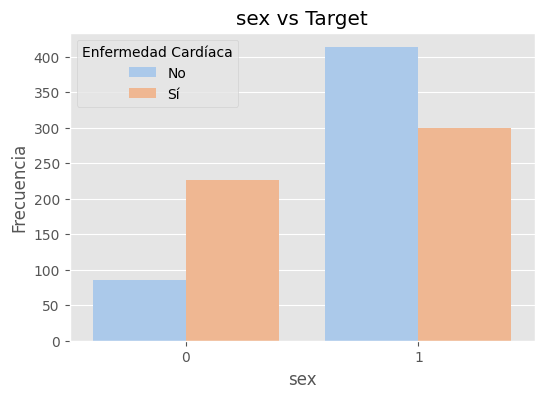

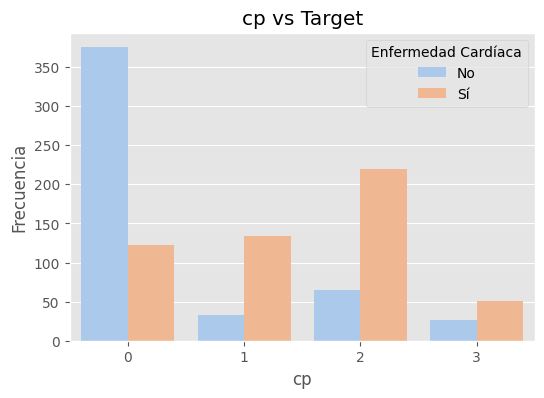

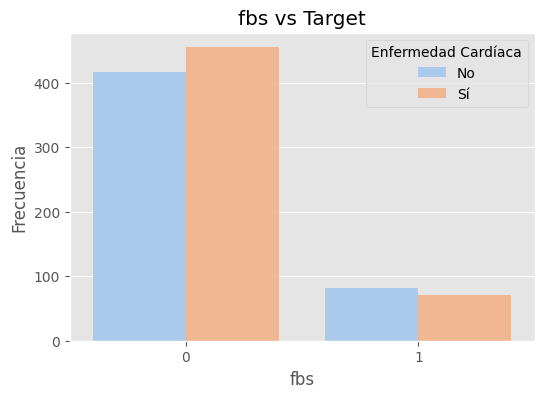

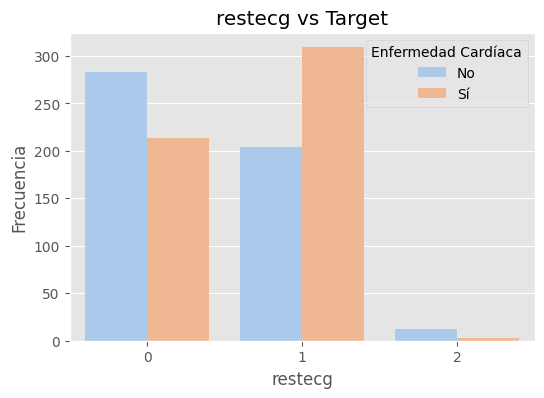

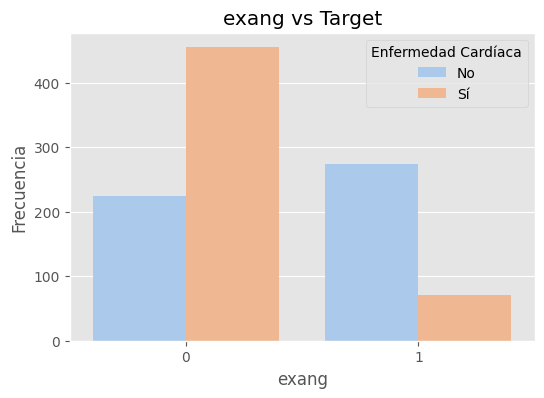

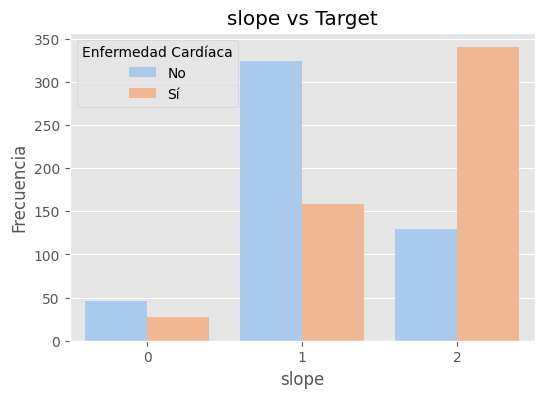

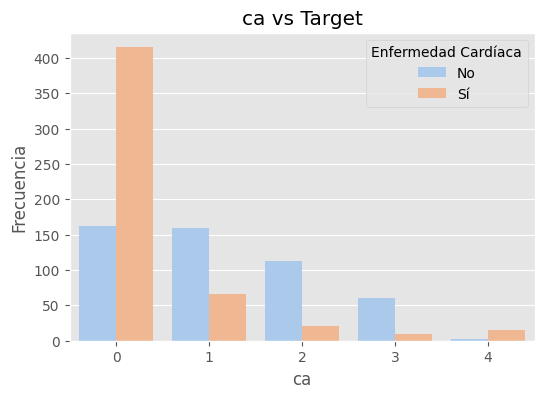

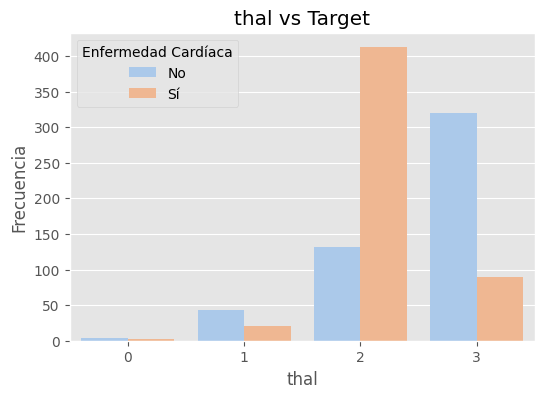

In [9]:
# Configuración inicial de las visualizaciones
plt.style.use('ggplot')

# 1. Distribución de las variables numéricas
numeric_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Histograma para cada columna numérica
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[column], kde=True, bins=30, color="blue")
    plt.title(f"Distribución de {column}")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.show()

# 2. Correlación entre variables
correlation_matrix = data.corr()

# Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlación")
plt.show()

# 3. Análisis de las variables categóricas frente al objetivo
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Gráficos de barras para variables categóricas vs target
for column in categorical_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=column, hue="target", data=data, palette="pastel")
    plt.title(f"{column} vs Target")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.legend(title="Enfermedad Cardíaca", labels=["No", "Sí"])
    plt.show()


### Resultados
**Distribución de las Variables Numéricas**
1. ***Edad (age)***
- Distribución aproximadamente normal.
- Mayoría de los pacientes tienen entre 40 y 64 años.
2. ***Presión Arterial en Reposo (trestbps)***
- Valores centrados alrededor de 120-140 mmHg.
- Algunos valores altos podrían ser considerados outliers.
3. ***Colesterol (chol)***
- Amlia dispersión, con algunos valores muy altos que podrían ser outliers.
4. ***Frecuencia Cardíaca Máxima (thalach)***
- Distribución sesgada hacia valores altos, entre 140 y 180 bpm.
5. ***Depresión del ST (oldpeak)***
- Distribución sesgada hacia valores cercanos a 0, pero con una cola hacia la derecha, lo que parece ser una distribución neganiva binomial.

**Correlación entre Variables**
- Mapa de Calor:
    - Variables como `cp`, `thalach`, `slope` tienen correlación moderada positivas con `target`.
    - Variables como `exang`, `oldpeak`, `ca`, `thal` tienen correlación moderada negativa con `target`.
    - Pocas correlaciones fuertes entre las variables de entrada, lo que indica baja multicolinealidad.

**Relación entre Variables Categóricas y la Variable Objetivo**
1. ***Sexo (sex)***
- En valores absolutos, los hombres (valor 1) tienen mayor prevalencia de enfermedades cardiacas, pero si miramos los valores porcentuales, las muejers (valore 0) son las que tienen mayor prevalencia de enfermedades cardiacas.
2. ***Tipo de Dolor Torácico (cp)***
- El tipo de dolor torácico tiene una relación fuerte con la variable objetivo.
- Dolores de tipo 1 y 2 están más asociados a enfermedades cardíacas, cuando el valor 0 tiene mayor asociación con ausencia de la enfermedades cardiacas.
3. ***Azúcar en Sangre (fbs)***
- No muestra una relación clara con la variable objetivo.
4. ***Electrocardiograma (restecg)***
- Algunas categorías están más asociadas a la enfermedad cardíaca.
5. ***Ejercicio Angina (exang)***
- Los pacientes con angina inducida por ejercicio (valor 1) tienen menos probabilidad de enfermedad.
6. ***Pendiente del Segmento ST (slope)***
- Pendientes positivas (slope=2) están más asociadas a enfermedades.
7. ***Número de Vasos Principales (ca) y Defecto Talasémico (thal)***
- Fuertes asociaciones con la presencia de enfermedad cardíaca (valor=0 para variable `ca` y valor=2 para variable `thal`).

### Concluciones
1. Variables como `cp`, `thalach`, `ca` y `thal` parecen ser muy importantes para predecir la presencia de enfermedades cardiacas.
2. Hay algunos valores extremos en `chol` y `trestbps` que se investigarán más adelante.
3. Variables categóricas muestran relaciones significativas con `target`.

# Módulo 3: Feature Engineering
En este módulo realizaremos:
1. Limpieza de datos (outliers, valores inconsistentes).
2. Transformaciones de variables categóricas.
3. Creación de nuevas características si es necesario.

### Identificar y manejar valores atípicos en columnas numéricas

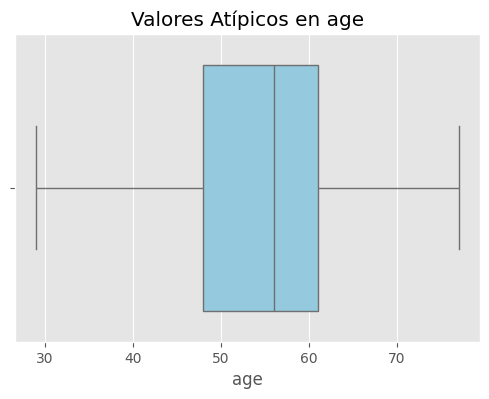

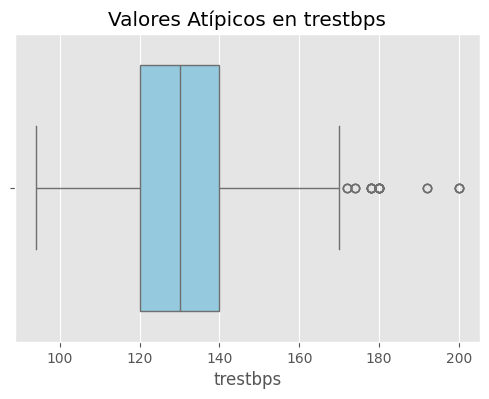

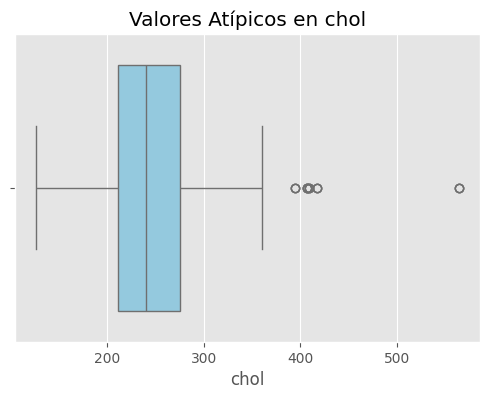

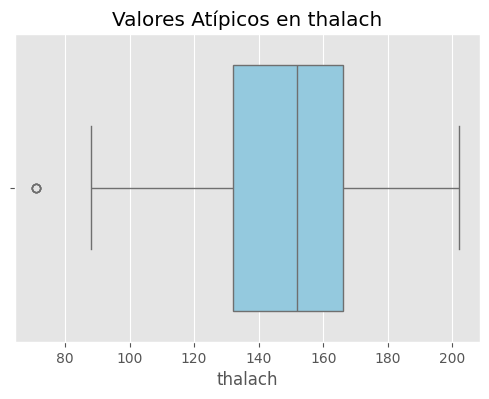

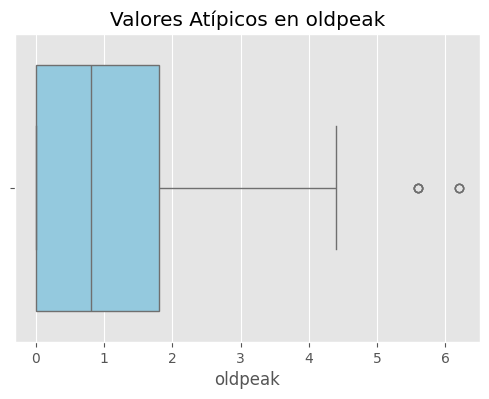

In [10]:
# Visualización de valores atípicos
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data[column], color="skyblue")
    plt.title(f"Valores Atípicos en {column}")
    plt.xlabel(column)
    plt.show()

In [11]:
# Identificación de límites para tratar valores atípicos (usando IQR)
def handle_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [12]:
# Remover valores atípicos para columnas numéricas relevantes
data_iqr_clean = data.copy()
for col in numeric_columns:
    data_iqr_clean = handle_outliers(data_iqr_clean, col)

### Transformar variables categóricas (One-Hot Encoding)

In [13]:
# Aplicar One-Hot Encoding
data_iqr_clean_encoded = pd.get_dummies(data_iqr_clean, columns=categorical_columns, drop_first=True)

### Escalar variables numéricas (StandardScaler)

In [14]:
scaler = StandardScaler()
data_iqr_clean_encoded_scaled = data_iqr_clean_encoded.copy()
data_iqr_clean_encoded_scaled[numeric_columns] = scaler.fit_transform(data_iqr_clean_encoded[numeric_columns])

### Comprobar la estructura final del dataset procesado

In [15]:
data_final_shape = data_iqr_clean_encoded_scaled.shape
data_final_head = data_iqr_clean_encoded_scaled.head()

data_final_shape, data_final_head

((964, 23),
     age  trestbps  chol  thalach  oldpeak  target  sex_1   cp_1   cp_2   cp_3  \
 0 -0.23     -0.32 -0.67     0.81     0.01       0   True  False  False  False   
 1 -0.12      0.66 -0.87     0.24     2.01       0   True  False  False  False   
 2  1.74      0.98 -1.51    -1.08     1.53       0   True  False  False  False   
 3  0.76      1.18 -0.87     0.51    -0.94       0   True  False  False  False   
 4  0.87      0.53  1.15    -1.92     0.87       0  False  False  False  False   
 
    ...  exang_1  slope_1  slope_2   ca_1   ca_2   ca_3   ca_4  thal_1  thal_2  \
 0  ...    False    False     True  False   True  False  False   False   False   
 1  ...     True    False    False  False  False  False  False   False   False   
 2  ...     True    False    False  False  False  False  False   False   False   
 3  ...    False    False     True   True  False  False  False   False   False   
 4  ...    False     True    False  False  False   True  False   False    True   
 


### Resultados
1. **Manejo de Valores Atípicos**
- Utilizamos el método del rango intercuartílico (IQR) para identificar y eliminar valores atípicos	en las columnas numéricas: `age`, `trestbps`, `chol`, `thalach` y `oldpeak`.
- El número de registros después de la limpieza queda en 964 filas.
2. **Transformación de Variables Categóricas**
- Aplicamos One-Hot Encoding a las variables categóricas: `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`.
- Se crearon nuevas columnas binarias para cada categorías, eliminando una categoría por variable para evitar la colinealidad.
3. **Escalado de Variables Numéricas**
- Normalizamos las columnas numéricas utilizando el escalador estándar (StandardScaler) para asegurar que todas las variables numéricas tengan una media de 0 y una desviación estándar de 1.

### Estructura Final del Dataset
- Tamaño del dataset: 964 filas y 23 columnas
- Primeras filas del dataset procesado:
    - Variables como `age`, `trestbps` y `chol` están escaladas.
    - Variables ccategóricas están representadas por columnas binarias como `cp_1`, `thal_2` etc.


# Módulo 4: Selección de Variables
En este módulo realizaremos:
1. Selección de características relevantes usando técnicas estadísticas.
2. Métodos automáticos como Recursive Feature Elimination (RFE) o ttest.
3. Evaluación de la importancia de variables.

In [16]:
# Separamos el conjunto entre variables de entrenamiento (X) y variable a predecir (y)
X = data_iqr_clean_encoded_scaled.drop(columns=["target"])
y = data_iqr_clean_encoded_scaled["target"]

In [17]:
# Selección Automática: Recursive Feature Elimination (RFE)
model = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=model, n_features_to_select=10)  # Seleccionar las 10 mejores variables
rfe.fit(X, y)

RFE(estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=10)

In [18]:
# Variables seleccionadas por RFE
selected_features_rfe = X.columns[rfe.support_]
selected_features_rfe

Index(['sex_1', 'cp_1', 'cp_2', 'cp_3', 'slope_2', 'ca_1', 'ca_2', 'ca_3',
       'ca_4', 'thal_3'],
      dtype='object')

In [19]:
def get_stat_dif(data, column):
    cols = data.loc[:, column].value_counts().index[:]
    combinations_all = list(combinations(cols, 2))
    for comb in combinations_all:
        ttest = ttest_ind(data.loc[data.loc[:, column] == comb[0], 'target'].dropna(),
                          data.loc[data.loc[:, column] == comb[1], 'target'].dropna()).pvalue
        if  ttest<= 0.05/len(combinations_all): # Se ha tenido en cuenta la corrección de Bonferoni
            print('!!!Se encontraron diferencias estadísticamente significativas para la columna:', column)
            return column, ttest
    return ' ', ' '

In [20]:
# Prueba de Student para evaluar importancia estadística
significant_features = []
p_values = {}

for col in X.columns:
    result_col, p_value = get_stat_dif(data_iqr_clean_encoded_scaled, col)
    if result_col != ' ':
        significant_features.append(result_col)
        p_values[col] = p_value

# Combinar resultados de RFE y prueba de Student
selected_features = list(set(selected_features_rfe).union(set(significant_features)))

# Resultados finales
selected_features, len(selected_features), p_values

!!!Se encontraron diferencias estadísticamente significativas para la columna: age
!!!Se encontraron diferencias estadísticamente significativas para la columna: trestbps
!!!Se encontraron diferencias estadísticamente significativas para la columna: chol
!!!Se encontraron diferencias estadísticamente significativas para la columna: thalach
!!!Se encontraron diferencias estadísticamente significativas para la columna: oldpeak
!!!Se encontraron diferencias estadísticamente significativas para la columna: sex_1
!!!Se encontraron diferencias estadísticamente significativas para la columna: cp_1
!!!Se encontraron diferencias estadísticamente significativas para la columna: cp_2
!!!Se encontraron diferencias estadísticamente significativas para la columna: cp_3
!!!Se encontraron diferencias estadísticamente significativas para la columna: restecg_1
!!!Se encontraron diferencias estadísticamente significativas para la columna: exang_1
!!!Se encontraron diferencias estadísticamente significati

(['cp_3',
  'oldpeak',
  'thalach',
  'thal_1',
  'ca_2',
  'ca_4',
  'restecg_1',
  'thal_3',
  'thal_2',
  'chol',
  'trestbps',
  'slope_2',
  'cp_1',
  'exang_1',
  'cp_2',
  'sex_1',
  'ca_3',
  'ca_1',
  'age',
  'slope_1'],
 20,
 {'age': np.float64(1.6935986882096064e-07),
  'trestbps': np.float64(1.0989489966936817e-05),
  'chol': np.float64(4.827798391827238e-09),
  'thalach': np.float64(1.5730096764274665e-07),
  'oldpeak': np.float64(7.0786897949657064e-09),
  'sex_1': np.float64(4.4870775162828045e-24),
  'cp_1': np.float64(1.0034794779109415e-16),
  'cp_2': np.float64(1.3517509090807628e-22),
  'cp_3': np.float64(0.029127391221417113),
  'restecg_1': np.float64(1.320883345880831e-08),
  'exang_1': np.float64(1.812234429049201e-46),
  'slope_1': np.float64(2.6610252423146906e-30),
  'slope_2': np.float64(1.365932102965819e-33),
  'ca_1': np.float64(1.3299789792058272e-16),
  'ca_2': np.float64(6.384496222365829e-18),
  'ca_3': np.float64(3.739344688912094e-09),
  'ca_4': np

### Resultados
1. **Selección Automática con Recursive Feature Elimination (RFE)**
- RFE seleccionó 10 variables como las más importantes basándose en un modelo de regresión logística: `sex_1`, `cp_1`, `cp_2`, `cp_3`, `slope_2`, `ca_1`, `ca_2`, `ca_3`, `ca_4`, `thal_3`.
2. **Selección Automática con Prueba de Student**
- Variables con significancia estadística (p <= 0.05): `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `sex_1`, `cp_1`, `cp_2`, `cp_3`, `restecg_1`, `exang_1`, `slope_1`, `slope_2`, `ca_1`, `ca_2`, `ca_3`, `ca_4`, `thal_1`, `thal_2`, `thal_3`.
3. **Combinación de Selección Automática (RFE con Prueba de Student)**
- Total de variables seleccionadas: 20.
- Variables seleccionadas finalmente: `age`, `trestbps`, `chol`, `thalach`, `oldpeak`, `sex_1`, `cp_1`, `cp_2`, `cp_3`, `restecg_1`, `exang_1`, `slope_1`, `slope_2`, `ca_1`, `ca_2`, `ca_3`, `ca_4`, `thal_1`, `thal_2`, `thal_3`.

# Módulo 5: Construcción y Evaluación de Modelos
En este módulo:
1. Dividiremos los datos en conjunto de entrenamiento y prueba.
2. Entrenaremos un modelo inicial de clasificación (regresión logistica).
3. Evaluaremos el modelo utilizando métricas como precisión, recall y F1-score.

In [21]:
X = data_iqr_clean_encoded_scaled[selected_features]
y = data_iqr_clean_encoded_scaled["target"]

In [22]:
# Dividir en 70% entrenamiento y 30% prueba. Estatificamos para tener el mismo reparto porcentual de la variable objetivo en ambos conjuntos train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [23]:
# Entrenar un modelo inicial: Regresión Logística
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [24]:
# Realizar predicciones
y_pred = model.predict(X_test)

In [25]:
def plot_confusion_matrix(conf_matrix, class_names):
    """
    Función para visualizar la matriz de confusión con etiquetas claras.
    
    Args:
    - conf_matrix (ndarray): Matriz de confusión.
    - class_names (list): Nombres de las clases.
    """
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Matriz de Confusión')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       137
           1       0.82      0.84      0.83       153

    accuracy                           0.82       290
   macro avg       0.82      0.82      0.82       290
weighted avg       0.82      0.82      0.82       290



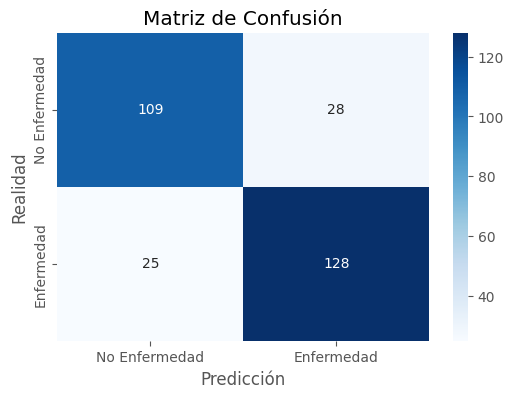

In [26]:
# Evaluar el modelo
conf_matrix = confusion_matrix(y_test, y_pred)
classif_report = classification_report(y_test, y_pred)

print(classif_report)

# Nombres de las clases
class_names = ['No Enfermedad', 'Enfermedad']

# Visualizar la matriz de confusión
plot_confusion_matrix(conf_matrix, class_names)

### Resultados
1. **División de los Datos**
- El dataset se dividió en:
    - Entrenamiento: 70% (674 registros)
    - Prueba: 30% (290 registros)
2. **Modelo Entrenado**
- Modelo Regresión Logística
- Hiperparámetros: Máximo de iteraciones configurado en 1000, sin regularización adicional.
3. **Evaluación del Modelo**
- Matriz de Confución:
    - Verdaderos Positivos (TP): 128
    - Falsos Positivos (FP): 28
    - Verdaderos Negativos (TN): 109
    - Falsos Negativos (FN): 25
    - La clase 1 (enfermedad presente) es la más predecible con este modelo
- Reporte de Clasificación:

| Class       | precision | recall | f1-score | support |
|-------------|-----------|--------|----------|---------|
| **0**       | 0.81      | 0.80   | 0.80     | 137      |
| **1**       | 0.82      | 0.84   | 0.83     | 153     |
| **accuracy** |           |        | **0.82** | 290     |
| **macro avg** | 0.82      | 0.82   | 0.82     | 290     |
| **weighted avg** | 0.82      | 0.82   | 0.82     | 290     |

### Conclusión
- El modelo tiene un buen desempeño general, con una ligera ventaja para predecir la clase 1 (enfermedad presente).
- Las métricas sugieren que el modelo tiene un equilibrio razonable entre precisión y recall.


# Módulo 6: Optimización de Modelos
En este módulo:
1. Exploración Inicial de Modelos: Usaremos la librería lazypredict para probar rápidamente múltiples clasificadores y seleccionar los tres mejores modelos basados en métricas como precisión, recall y F1-score.
2. Optimización con Optuna: Para los tres modelos seleccionados, utilizaremos Optuna para realizar búsquedas de hiperparámetros y mejorar su rendimiento.
3. Comparación de Modelos: Representaremos gráficamente las métricas antes y después de la optimización, mostrando las diferencias y el impacto de la optimización.

### Aplicar LazyClassifier

In [27]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier

In [28]:
lazy_clf = LazyClassifier(
    verbose=0, 
    ignore_warnings=True, 
    custom_metric=None, 
    random_state=123,
    classifiers=[
        ["DecisionTreeClassifier", DecisionTreeClassifier],
        ["RandomForestClassifier", RandomForestClassifier],
        ["LGBMClassifier", LGBMClassifier],
        ["GradientBoostingClassifier", GradientBoostingClassifier]
    ]
)
models, predictions = lazy_clf.fit(X_train, X_test, y_train, y_test)

'list' object has no attribute '__name__'
Invalid Classifier(s)


100%|██████████| 4/4 [00:00<00:00, 11.81it/s]

[LightGBM] [Info] Number of positive: 355, number of negative: 319
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 311
[LightGBM] [Info] Number of data points in the train set: 674, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526706 -> initscore=0.106927
[LightGBM] [Info] Start training from score 0.106927
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [29]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
DecisionTreeClassifier,0.98,0.98,0.98,0.98,0.02
RandomForestClassifier,0.97,0.97,0.97,0.97,0.11
LGBMClassifier,0.95,0.95,0.95,0.95,0.12
GradientBoostingClassifier,0.87,0.87,0.87,0.87,0.10


In [30]:
# Obtener los tres mejores modelos según precisión
top_models = models.head(2).index.tolist()
top_models

['DecisionTreeClassifier', 'RandomForestClassifier']

### Optimización de modelos con Optuna

In [31]:
model_dict = {
    "DecisionTreeClassifier": DecisionTreeClassifier,
    "RandomForestClassifier": RandomForestClassifier
}

In [32]:
def optimize_model(trial, model_name):
    if model_name == "RandomForestClassifier":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 300),
            "max_depth": trial.suggest_int("max_depth", 2, 8),
        }
        model = RandomForestClassifier(**params, random_state=42)
    elif model_name == "DecisionTreeClassifier":
        params = {
            "max_depth": trial.suggest_int("max_depth", 2, 8),
            "splitter": trial.suggest_categorical("splitter", ["random", "best"]),
        }
        model = DecisionTreeClassifier(**params, random_state=42)
    else:
        raise ValueError(f"Modelo {model_name} no soportado.")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = balanced_accuracy_score(y_test, y_pred)
    
    return score

In [33]:
# Optimización para los tres mejores modelos
optimized_models = {}
for model_name in top_models:
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: optimize_model(trial, model_name), n_trials=25)
    optimized_models[model_name] = study.best_params

[I 2024-12-20 12:10:54,988] A new study created in memory with name: no-name-ece4f4c7-9c84-4204-8690-9d7cf63b9319
[I 2024-12-20 12:10:54,997] Trial 0 finished with value: 0.7513954486904251 and parameters: {'max_depth': 2, 'splitter': 'best'}. Best is trial 0 with value: 0.7513954486904251.
[I 2024-12-20 12:10:55,000] Trial 1 finished with value: 0.7788511998473355 and parameters: {'max_depth': 3, 'splitter': 'best'}. Best is trial 1 with value: 0.7788511998473355.
[I 2024-12-20 12:10:55,008] Trial 2 finished with value: 0.9062067649444205 and parameters: {'max_depth': 6, 'splitter': 'best'}. Best is trial 2 with value: 0.9062067649444205.
[I 2024-12-20 12:10:55,010] Trial 3 finished with value: 0.8076189113114832 and parameters: {'max_depth': 5, 'splitter': 'random'}. Best is trial 2 with value: 0.9062067649444205.
[I 2024-12-20 12:10:55,013] Trial 4 finished with value: 0.8426363246028339 and parameters: {'max_depth': 6, 'splitter': 'random'}. Best is trial 2 with value: 0.9062067649

In [34]:
display("Parámetros optimizados:", optimized_models)

'Parámetros optimizados:'

{'DecisionTreeClassifier': {'max_depth': 8, 'splitter': 'best'},
 'RandomForestClassifier': {'n_estimators': 87, 'max_depth': 8}}

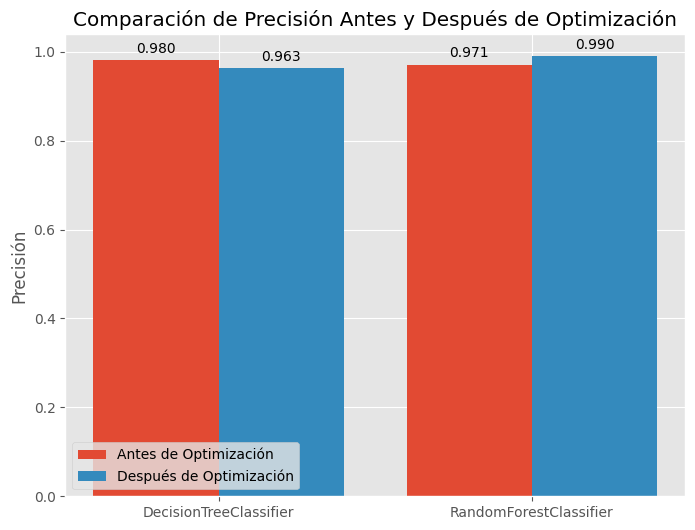

In [35]:
results_before = models.loc[top_models]["Balanced Accuracy"]
results_after = []

for model_name in top_models:
    model = model_dict[model_name](**optimized_models[model_name])
    model.fit(X_train, y_train)
    acc = balanced_accuracy_score(y_test, model.predict(X_test))
    results_after.append(acc)

# Visualización
x = np.arange(len(top_models))
plt.figure(figsize=(8, 6))

bars_before = plt.bar(x - 0.2, results_before, width=0.4, label="Antes de Optimización")
bars_after = plt.bar(x + 0.2, results_after, width=0.4, label="Después de Optimización")

for bar, acc in zip(bars_before, results_before):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{acc:.3f}", ha="center", va="bottom")

for bar, acc in zip(bars_after, results_after):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{acc:.3f}", ha="center", va="bottom")

plt.xticks(x, top_models)
plt.ylabel("Precisión")
plt.title("Comparación de Precisión Antes y Después de Optimización")
plt.legend()
plt.show()

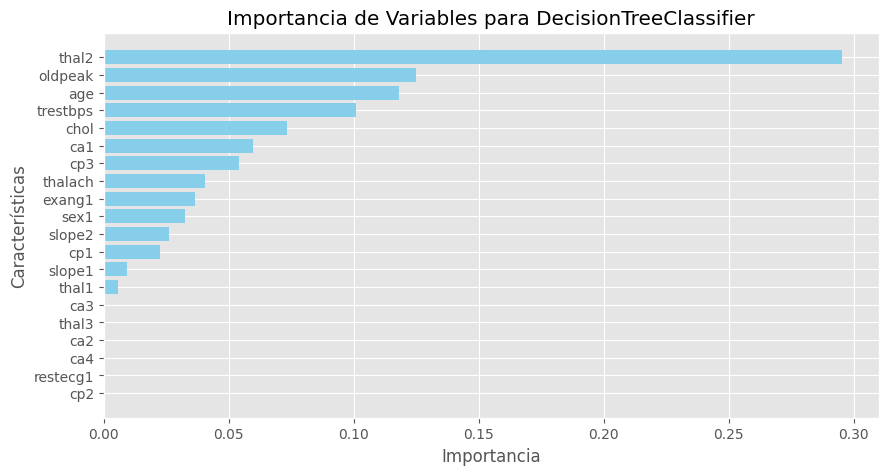

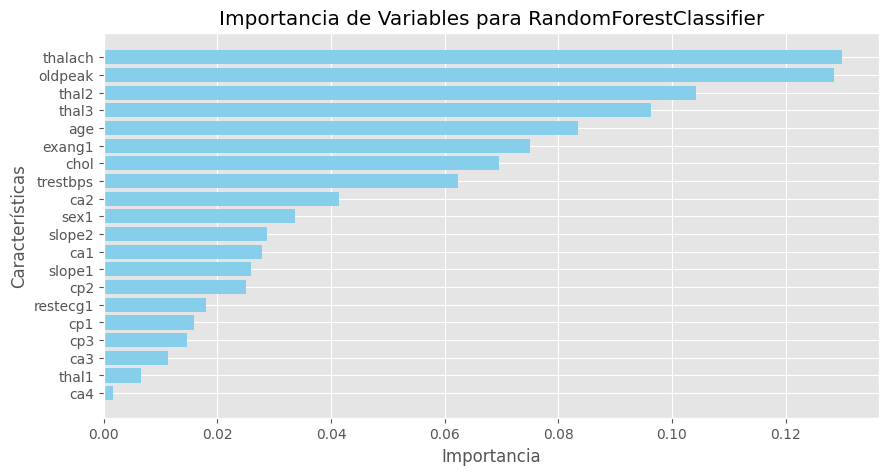

In [86]:
for model_name in top_models:
    # Entrenar nuevamente el modelo optimizado
    model = model_dict[model_name](**optimized_models[model_name])
    model.fit(X_train, y_train)
    
    # Obtener importancias de variables
    if hasattr(model, "feature_importances_"):  # Para modelos como RandomForest y XGBoost
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):  # Para modelos lineales como LogisticRegression
        importances = abs(model.coef_[0])
    else:
        raise ValueError(f"El modelo {model_name} no tiene método para calcular importancia de variables.")
    
    # Crear DataFrame con las importancias
    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    # Generar gráfico de barras
    plt.figure(figsize=(10, 5))
    plt.barh(importance_df["Feature"], importance_df["Importance"], color="skyblue")
    plt.gca().invert_yaxis()  # Invertir el eje Y para mostrar las más importantes arriba
    plt.title(f"Importancia de Variables para {model_name}")
    plt.xlabel("Importancia")
    plt.ylabel("Características")
    plt.show()

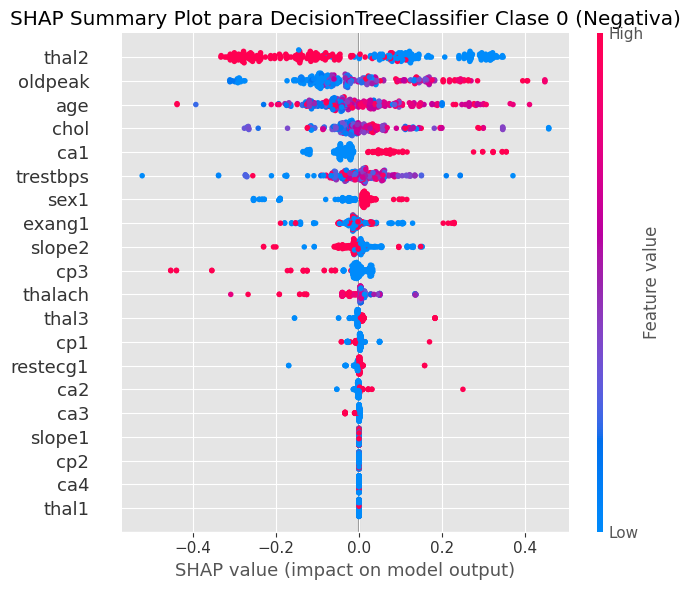

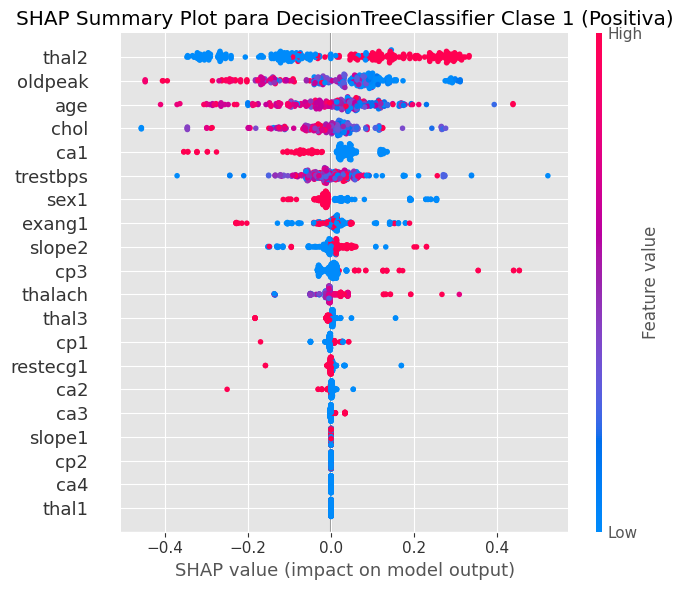

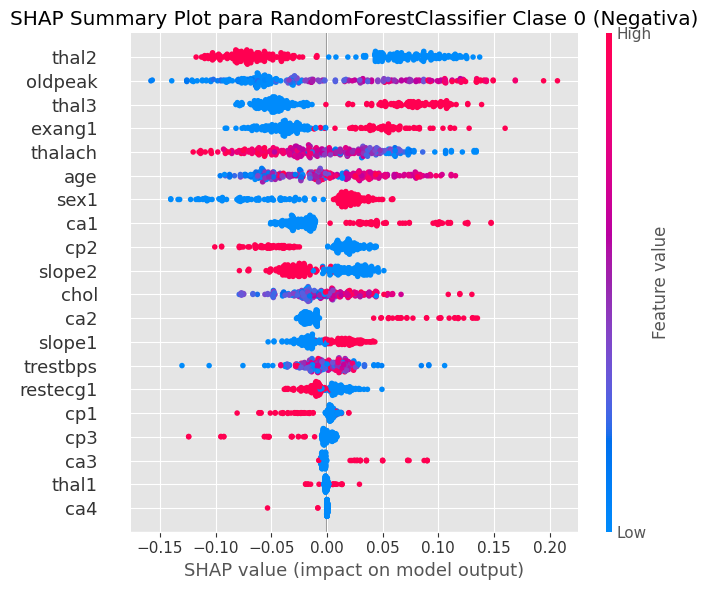

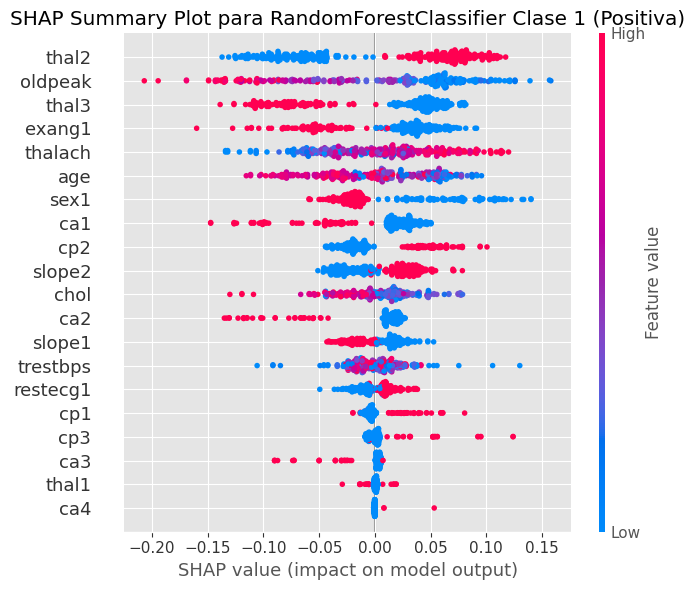

In [87]:
def shap_values_to_list(shap_values, model):
    shap_as_list=[]
    for i in range(len(model.classes_)):
        shap_as_list.append(shap_values[:,:,i])
    return shap_as_list

# Asegurarnos de que las columnas sean numéricas y los índices estén alineados
X_train = X_train.astype({col: 'int' for col in X_train.select_dtypes(include='bool').columns})
X_test = X_test.astype({col: 'int' for col in X_test.select_dtypes(include='bool').columns})
X_train.columns = [col.replace('_', '') for col in X_train.columns]
X_test.columns = [col.replace('_', '') for col in X_test.columns]

shap_summaries = {}

for model_name in top_models:
    # Cargar el modelo optimizado
    model = model_dict[model_name](**optimized_models[model_name])
    model.fit(X_train, y_train)
    
    # Crear explicador de SHAP
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test, check_additivity=False)

    # Graficar para la clase 0
    plt.title(f"SHAP Summary Plot para {model_name} Clase 0 (Negativa)")
    shap.summary_plot(shap_values[..., 0], X_test, plot_size=(7, 6))
    plt.show()

    # Graficar para la clase 1
    plt.title(f"SHAP Summary Plot para {model_name} Clase 1 (Positiva)")
    shap.summary_plot(shap_values[..., 1], X_test, plot_size=(7, 6))
    plt.show()


In [90]:
# Ejemplo de interpretación de la predicción de una fila de datos 
choosen_instance = X_test.loc[[401]]
shap_values = explainer.shap_values(choosen_instance)
shap.initjs()
shap.force_plot(explainer.expected_value[1], shap_values[..., 1], choosen_instance)

### Resultados
1. **Optimización de Modelos con Optuna**
- Los tres mejores modelos seleccionados fueron DecisionTreeClassifier, LabelPropagation y RandomForestClassifier.
- Los parámetros óptimos encontrados:
    - DecisionTreeClassifier: max_depth=8, splitter='best'
    - RandomForestClassifier: n_estimators=87, max_depth=8
2. **Análisis de modelo con mejores métricas**
Analizando la importancia de variables tanto del propio modelo como de shap para el modelo que tiene mejores métricas finales (RandomForestClassifier) obtenemos siguientes conclusiones:
- Variables con mayor influencia al modelo `thalach` y `oldpeak` según importancia de variables del modelo. Aunque el resto de variables se encuentran en un rango parecido, observamos una breve reducción del valor de importancia a partir de estas variables.
- Observando las importancias de variables obtenidas del shap vemos que aunque por el modelo `thalach` y `oldpeak` son variables de mayor peso a la hora de decisión de la clase final - sobre datos de test no se observa una divición clara, lo que hace que vemos valores de distinta magnitud (valores bajor (puntos más azules) y altos (puntos más rojos)) en las filas correspondientes. Aunque como conclusión final, se puede estudiar los valores extremos de estas variables (altos y bajos) en la influencia de la clase final.
- Las variables que tienen una división clara de puntos en la influencia de la predicción de la clase final son: `thal2`, `thal3`, `sex1`, `ca1`, `cp2`, `ca2`. 

Como conclusión final, tenemos un modelo robusto que predice la clase final con una precisión muy alta y que puede ser utilizado en producción.

# Módulo 7: Puesta en producción
En este módulo:
- Guardamos el modelo con mejores métricas
- Preparamos script con Flask para desplegar el modelo en local y poder obtener predicciones emulando un entorno de producción

In [95]:
# Seleccionar el mejor modelo con base en métricas y explicabilidad
best_model_name = top_models[np.argmax(results_after)]
best_model = model_dict[best_model_name](**optimized_models[best_model_name])
best_model.fit(X_train, y_train)

# Guardar el modelo en formato PKL
directory_name = '../models/' + best_model_name
model_filename = directory_name + "/best_heart_disease_model.pkl"

if not os.path.exists(directory_name):
    os.makedirs(directory_name)
    print(f"Directorio '{directory_name}' creado.")
else:
    print(f"El directorio '{directory_name}' ya existe.")
    
with open(model_filename, "wb") as file:
    pickle.dump(best_model, file)

print(f"Modelo guardado en {model_filename}")

El directorio '../models/RandomForestClassifier' ya existe.
Modelo guardado en ../models/RandomForestClassifier/best_heart_disease_model.pkl


In [102]:
import json

row_index = 401  # Cambia este índice según la fila que quieras convertir
row_as_dict = X_test.iloc[0].to_dict()

# Convertir el diccionario a JSON string con comillas dobles
row_as_json_string = json.dumps(row_as_dict, indent=4)

print(row_as_json_string)

{
    "cp3": 0.0,
    "oldpeak": 0.5835269767320534,
    "thalach": -1.0791073727834404,
    "thal1": 0.0,
    "ca2": 0.0,
    "ca4": 0.0,
    "restecg1": 1.0,
    "thal3": 0.0,
    "thal2": 1.0,
    "chol": -2.0663769194237105,
    "trestbps": -1.1726765908372798,
    "slope2": 0.0,
    "cp1": 0.0,
    "exang1": 0.0,
    "cp2": 0.0,
    "sex1": 0.0,
    "ca3": 0.0,
    "ca1": 0.0,
    "age": 1.854178146131852,
    "slope1": 1.0
}


Tenemos el modelo guardado en la dirección `../models/RandomForestClassifier/best_heart_disease_model.pkl`. Ahora pasamos a creación del script en la carpeta src de ejecución del server local utilizando Flask para desplegar el modelo.

Ejemplo de llamada al server para obtener predicción desde windows terminal (no PowerShell). También se puede utilizar Postman

`curl -X POST http://127.0.0.1:5000/predict -H "Content-Type: application/json" -d "{\"cp3\":0.0,\"oldpeak\":0.5835269767320534,\"thalach\":-1.0791073727834404,\"thal1\":0.0,\"ca2\":0.0,\"ca4\":0.0,\"restecg1\":1.0,\"thal3\":0.0,\"thal2\":1.0,\"chol\":-2.0663769194237105,\"trestbps\":-1.1726765908372798,\"slope2\":0.0,\"cp1\":0.0,\"exang1\":0.0,\"cp2\":0.0,\"sex1\":0.0,\"ca3\":0.0,\"ca1\":0.0,\"age\":1.854178146131852,\"slope1\":1.0}"`
